# Chapter 05 — Meat Proxy

**Companion to *Applied AI*.**

This notebook accompanies Chapter 5. The chapter's claim is that a reviewer
becomes a rubber stamp because of the system's **successes**, not its failures,
and that discipline does not fix it.

## Question

As a system gets more reliable, what happens to what a reviewer actually
catches — and **which review strategy still tells you when quality degrades?**

## What this notebook establishes

- A mechanism in which every individual decision to look less closely is
  locally rational, and the escape rate rises anyway.
- A comparison of four review strategies on identical streams, scored on two
  separate things: defects caught, and whether the strategy yields an
  **error-rate estimate** at all.
- Why only deep sampling and seeded defects produce a number you can act on.
- The blast-radius arithmetic: what an undetected escape costs when nobody
  recorded what was checked.

## What this notebook does **not** establish

- **This is a simulation, and it is not a model of human attention.** It does
  not reproduce, test, or extend the automation-bias literature the chapter
  cites (Parasuraman & Manzey; Lee et al.; Dell'Acqua et al.). Those are
  measured studies of real people with stated bounds; this is arithmetic.
- The decay rule below is **invented for teaching**. Its shape is a design
  choice, not a finding.
- No claim is made about what any real reviewer's catch rate is. The chapter's
  advice is to *measure your own*, which is a thing you do with seeded defects
  and not with a notebook.

## Setup

In [1]:
import random
import statistics
from dataclasses import dataclass, field

SEED = 42

## The mechanism

A stream of items. A fraction are defective. The reviewer's attention depends
on the recent run of clean results — which is the chapter's point: **updating
on the evidence you have is what produces the proxy.**

In [2]:
@dataclass
class Reviewer:
    """Attention falls as consecutive clean results accumulate.

    The decay rule is invented for this notebook. It encodes only the
    chapter's claim that each step down is locally rational.
    """
    base_catch: float = 0.92     # catch probability when fully attentive
    floor: float = 0.05          # catch probability once fully complacent
    decay_after: int = 5         # clean items before attention starts falling
    halflife: int = 12
    clean_run: int = 0

    def attention(self) -> float:
        over = max(0, self.clean_run - self.decay_after)
        frac = 0.5 ** (over / self.halflife)
        return self.floor + (self.base_catch - self.floor) * frac

    def review(self, is_defective: bool, rng) -> bool:
        """Returns True if the defect was caught."""
        p = self.attention()
        caught = is_defective and rng.random() < p
        if is_defective and caught:
            self.clean_run = 0
        else:
            self.clean_run += 1
        return caught

def run_stream(defect_rate, n=4000, seed=SEED):
    rng = random.Random(seed)
    r = Reviewer()
    escapes, caught, attention_trace = 0, 0, []
    for _ in range(n):
        d = rng.random() < defect_rate
        attention_trace.append(r.attention())
        if r.review(d, rng):
            caught += 1
        elif d:
            escapes += 1
    return {
        "defect_rate": defect_rate,
        "defects": caught + escapes,
        "caught": caught,
        "escaped": escapes,
        "final_attention": r.attention(),
        "mean_attention": statistics.fmean(attention_trace),
    }

## Experiment: the system gets better

Hold the reviewer fixed and make the system more reliable. The chapter's
inversion says the reviewer gets *worse* as the system gets better.

In [3]:
rows = [run_stream(d) for d in (0.30, 0.10, 0.05, 0.02, 0.005)]

print(f"{'defect rate':<14}{'defects':<10}{'caught':<10}{'escaped':<10}"
      f"{'catch rate':<13}{'mean attention'}")
print("-" * 75)
for r in rows:
    cr = r["caught"] / r["defects"] if r["defects"] else float("nan")
    print(f"{r['defect_rate']:<14.1%}{r['defects']:<10}{r['caught']:<10}"
          f"{r['escaped']:<10}{cr:<13.1%}{r['mean_attention']:.2f}")

defect rate   defects   caught    escaped   catch rate   mean attention
---------------------------------------------------------------------------
30.0%         1193      1028      165       86.2%        0.87
10.0%         378       97        281       25.7%        0.24
5.0%          179       20        159       11.2%        0.11
2.0%          69        2         67        2.9%         0.06
0.5%          17        1         16        5.9%         0.06


## Observation

Read the last two columns together. At a 30% defect rate the reviewer stays
sharp, because they cannot afford not to. At 0.5% their attention collapses and
the proportion of defects that *escape* is at its worst.

> **You are not turned into a rubber stamp by the system's failures. You are
> turned into one by its successes.**

Nothing in the simulation models laziness. The reviewer's rule is to relax
after a run of clean results, which is a correct update on the data available.

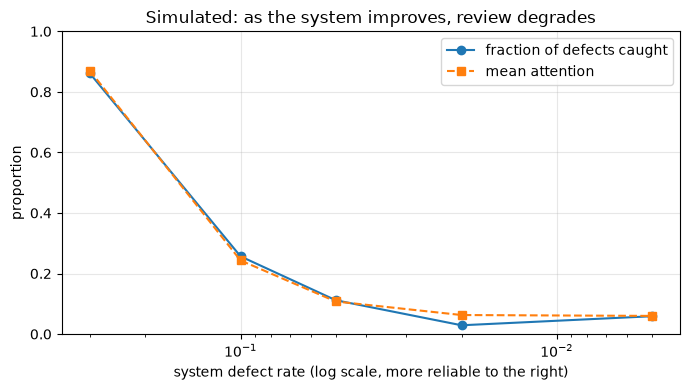

Simulation, not a measurement of human reviewers. Decay rule is invented.


In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
xs = [r["defect_rate"] for r in rows]
catch = [r["caught"] / r["defects"] for r in rows]
ax.plot(xs, catch, marker="o", label="fraction of defects caught")
ax.plot(xs, [r["mean_attention"] for r in rows], marker="s",
        linestyle="--", label="mean attention")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel("system defect rate (log scale, more reliable to the right)")
ax.set_ylabel("proportion")
ax.set_ylim(0, 1)
ax.set_title("Simulated: as the system improves, review degrades")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Simulation, not a measurement of human reviewers. Decay rule is invented.")

## Four review strategies on the same stream

The chapter's shallow-review section lists what to do if the review is going to
be shallow anyway. Score them on two different things.

In [5]:
DEFECT_RATE = 0.02
N = 4000

MECHANICAL_SHARE = 0.55   # share of defects a mechanical check can define

def strategy_universal_skim(rng):
    r = Reviewer(base_catch=0.35, floor=0.03, decay_after=3, halflife=8)
    caught = escaped = defects = 0
    for _ in range(N):
        d = rng.random() < DEFECT_RATE
        defects += d
        if r.review(d, rng):
            caught += 1
        elif d:
            escaped += 1
    return dict(name="universal skim", defects=defects, caught=caught,
                escaped=escaped, reviewed=N, estimate=None)

def strategy_deep_sample(rng, frac=0.05):
    r = Reviewer(base_catch=0.95, floor=0.80, decay_after=10_000)  # stays sharp
    caught = escaped = defects = 0
    sampled = sampled_defects = sampled_caught = 0
    for _ in range(N):
        d = rng.random() < DEFECT_RATE
        defects += d
        if rng.random() < frac:
            sampled += 1
            sampled_defects += d
            if r.review(d, rng):
                caught += 1
                sampled_caught += 1
            elif d:
                escaped += 1
        elif d:
            escaped += 1
    est = sampled_defects / sampled if sampled else float("nan")
    se = (est * (1 - est) / sampled) ** 0.5 if sampled else float("nan")
    return dict(name="deep random 5%", defects=defects, caught=caught,
                escaped=escaped, reviewed=sampled, estimate=(est, se))

def strategy_mechanical(rng):
    caught = escaped = defects = 0
    for _ in range(N):
        d = rng.random() < DEFECT_RATE
        defects += d
        if d and rng.random() < MECHANICAL_SHARE:
            caught += 1
        elif d:
            escaped += 1
    return dict(name="mechanical checks", defects=defects, caught=caught,
                escaped=escaped, reviewed=N, estimate=None)

def strategy_seeded(rng, n_seeded=200):
    """Mechanical checks plus seeded defects to measure the catch rate."""
    base = strategy_mechanical(rng)
    seeded_caught = sum(1 for _ in range(n_seeded)
                        if rng.random() < MECHANICAL_SHARE)
    rate = seeded_caught / n_seeded
    se = (rate * (1 - rate) / n_seeded) ** 0.5
    base = dict(base)
    base["name"] = "mechanical + seeded"
    base["estimate"] = (rate, se)
    return base

rng = random.Random(SEED)
results = [strategy_universal_skim(rng), strategy_deep_sample(rng),
           strategy_mechanical(rng), strategy_seeded(rng)]

print(f"{'strategy':<22}{'defects':<9}{'caught':<9}{'escaped':<9}"
      f"{'items looked at':<18}{'estimate produced'}")
print("-" * 98)
for r in results:
    if r["estimate"] is None:
        est = "NONE"
    else:
        v, se = r["estimate"]
        est = f"{v:.3f} +/- {se:.3f}"
    print(f"{r['name']:<22}{r['defects']:<9}{r['caught']:<9}{r['escaped']:<9}"
          f"{r['reviewed']:<18}{est}")
print()
print("What each estimate is OF - they are not the same quantity:")
print("  deep random 5%       -> the DEFECT RATE of the stream (+/- 1 s.e.)")
print("  mechanical + seeded  -> the CATCH RATE of the review itself (+/- 1 s.e.)")
print("  universal skim       -> nothing: no denominator, so no estimate")
print("  mechanical checks    -> nothing: catches a fixed class, measures neither")

strategy              defects  caught   escaped  items looked at   estimate produced
--------------------------------------------------------------------------------------------------
universal skim        69       1        68       4000              NONE
deep random 5%        73       2        71       189               0.011 +/- 0.007
mechanical checks     76       48       28       4000              NONE
mechanical + seeded   91       43       48       4000              0.570 +/- 0.035

What each estimate is OF - they are not the same quantity:
  deep random 5%       -> the DEFECT RATE of the stream (+/- 1 s.e.)
  mechanical + seeded  -> the CATCH RATE of the review itself (+/- 1 s.e.)
  universal skim       -> nothing: no denominator, so no estimate
  mechanical checks    -> nothing: catches a fixed class, measures neither


## Interpretation

The last column is the one the chapter cares about, and it is not the same as
the "caught" column.

**Universal skim looks at every item and produces nothing you can act on.** It
has no denominator, so it cannot tell you the error rate, and it cannot tell
you when the error rate changes. You find out from a customer.

**Deep sampling looks at a twentieth as many items and produces an estimate
with an interval.** That estimate is what detects degradation.

**Seeded defects measure the reviewer rather than the stream**, which is the
only honest answer to "is my review still worth anything?" — the chapter's
closing exercise and the one number nobody else can produce for you.

## The blast radius

The chapter's catastrophic failure is not the escaped defect. It is that when
one is finally found, nobody can say how far back it goes.

In [6]:
def blast_radius(n_items, recorded: bool, escaped: int):
    if recorded:
        # Each record names what was checked, so only unchecked items are suspect.
        suspect = escaped * 12      # a bounded neighbourhood, illustrative
        return min(suspect, n_items), "bounded: these items, and here is why"
    return n_items, "unbounded: every item is suspect"

esc = results[0]["escaped"]
for recorded in (True, False):
    n, note = blast_radius(N, recorded, esc)
    label = "with a record of what was checked" if recorded else "approvals only"
    print(f"{label:<36} items to re-examine: {n:>5}   {note}")

with a record of what was checked    items to re-examine:   816   bounded: these items, and here is why
approvals only                       items to re-examine:  4000   unbounded: every item is suspect


The difference between those two rows is not review quality. It is whether the
process wrote down what each approval was based on — which is the machinery
Chapters 14, 16, 17 and 18 build, and the reason the chapter calls them
something other than administrative overhead.

## Try it yourself

1. **Set `base_catch = 1.0` and `floor = 1.0`.** A perfect, never-tiring
   reviewer. The escapes go to zero — and this is exactly the reviewer the
   chapter says thirty years of research says you do not have. Which of your
   own processes assumes this reviewer?
2. **Change the decay rule.** Make attention depend on time rather than on the
   clean run. Does the qualitative result survive? If it does, the result is
   about the structure rather than about your parameters.
3. **Vary the sample fraction** from 1% to 50% and plot the width of the
   estimate's interval. How small a sample still detects a doubling of the
   error rate?
4. **Seed a defect class the mechanical check cannot see** (set its catch
   probability to 0) and re-run the seeded strategy. Watch the measured catch
   rate stay high while the real escapes rise. That is Chapter 21's adequacy
   problem arriving in the review layer.